In [12]:
import os
import awkward

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
# from torch.utils.tensorboard import SummaryWriter

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

import transformer_encoder_template as tt

In [28]:
# reload import
%load_ext autoreload
%autoreload 2
from helper import normalize_dataset, collate_fn_gnn, train_model, plot_loss, evaluate_model, load_best_model

In [14]:
path = 'IceCube_2D_Dataset/'

train_dataset = awkward.from_parquet(os.path.join(path, 'train.pq'))
val_dataset = awkward.from_parquet(os.path.join(path, 'val.pq'))
test_dataset = awkward.from_parquet(os.path.join(path, 'test.pq'))

In [15]:
train_dataset, train_stats = normalize_dataset(train_dataset)

val_dataset, _ = normalize_dataset(val_dataset, stats=train_stats)

test_dataset, _ = normalize_dataset(test_dataset, stats=train_stats)

In [16]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=tt.collate_fn_transformer)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=tt.collate_fn_transformer)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=tt.collate_fn_transformer)

In [17]:
model = tt.TransformerEncoder(
    input_dim = 3,
    d_model = 64,
    output_dim = 2,
    num_layers = 2,
    nhead = 2,
)


/Users/frederikzielke/Uni/Deep-Learning/Advanced/Transformers/transformer_encoder_template.py:86: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


In [18]:
loss_function = nn.MSELoss()
learning_rate = 1e-4
num_epochs = 100
patience = 10
model_name = "transformer_encoder_model"
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


Using device: mps


In [19]:
model.to(device)

TransformerEncoder(
  (input_embedding): Linear(in_features=3, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.02, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.02, inplace=False)
        (dropout2): Dropout(p=0.02, inplace=False)
      )
    )
  )
  (output_projection): Linear(in_features=64, out_features=2, bias=True)
)

In [20]:
train_losses, val_losses, best_model = train_model(model, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience, device, model_name=model_name)


Epoch [1/100], Step [310/313], Loss: 0.8246
Epoch [1/100], Train Loss: 2.7869, Val Loss: 1.2635, Time: 6.86 seconds, Patience Counter: 0/10
Epoch [2/100], Step [310/313], Loss: 1.2166
Epoch [2/100], Train Loss: 1.0657, Val Loss: 0.9559, Time: 6.98 seconds, Patience Counter: 0/10
Epoch [3/100], Step [310/313], Loss: 0.6236
Epoch [3/100], Train Loss: 0.8775, Val Loss: 0.8520, Time: 6.71 seconds, Patience Counter: 0/10
Epoch [4/100], Step [310/313], Loss: 0.7650
Epoch [4/100], Train Loss: 0.8051, Val Loss: 0.8129, Time: 6.67 seconds, Patience Counter: 0/10
Epoch [5/100], Step [310/313], Loss: 0.5664
Epoch [5/100], Train Loss: 0.7504, Val Loss: 0.7942, Time: 6.63 seconds, Patience Counter: 0/10
Epoch [6/100], Step [310/313], Loss: 0.9249
Epoch [6/100], Train Loss: 0.7217, Val Loss: 0.7572, Time: 6.80 seconds, Patience Counter: 0/10
Epoch [7/100], Step [310/313], Loss: 1.0272
Epoch [7/100], Train Loss: 0.6973, Val Loss: 0.7697, Time: 6.76 seconds, Patience Counter: 0/10
Epoch [8/100], Step 

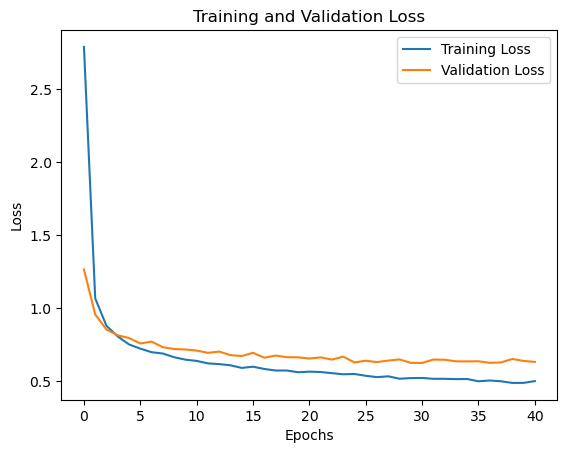

In [22]:
# plot losses
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [32]:
import importlib
import helper  # assuming your file is named helper.py

# 1. Force the kernel to reload the file from disk
importlib.reload(helper)

# 2. Re-import the specific function into your current namespace
from helper import evaluate_model

<unknown>:361: SyntaxWarning: invalid escape sequence '\D'
<unknown>:391: SyntaxWarning: invalid escape sequence '\D'
<unknown>:427: SyntaxWarning: invalid escape sequence '\D'


In [25]:
# load the best model
best_model = load_best_model(model, model_path='models/transformer_encoder_model.pth', device=device)

Validation MSE Loss: 0.5820
Mean Error Distance: 0.75 meters
Median Error Distance: 0.48 meters

Generating evaluation plots...


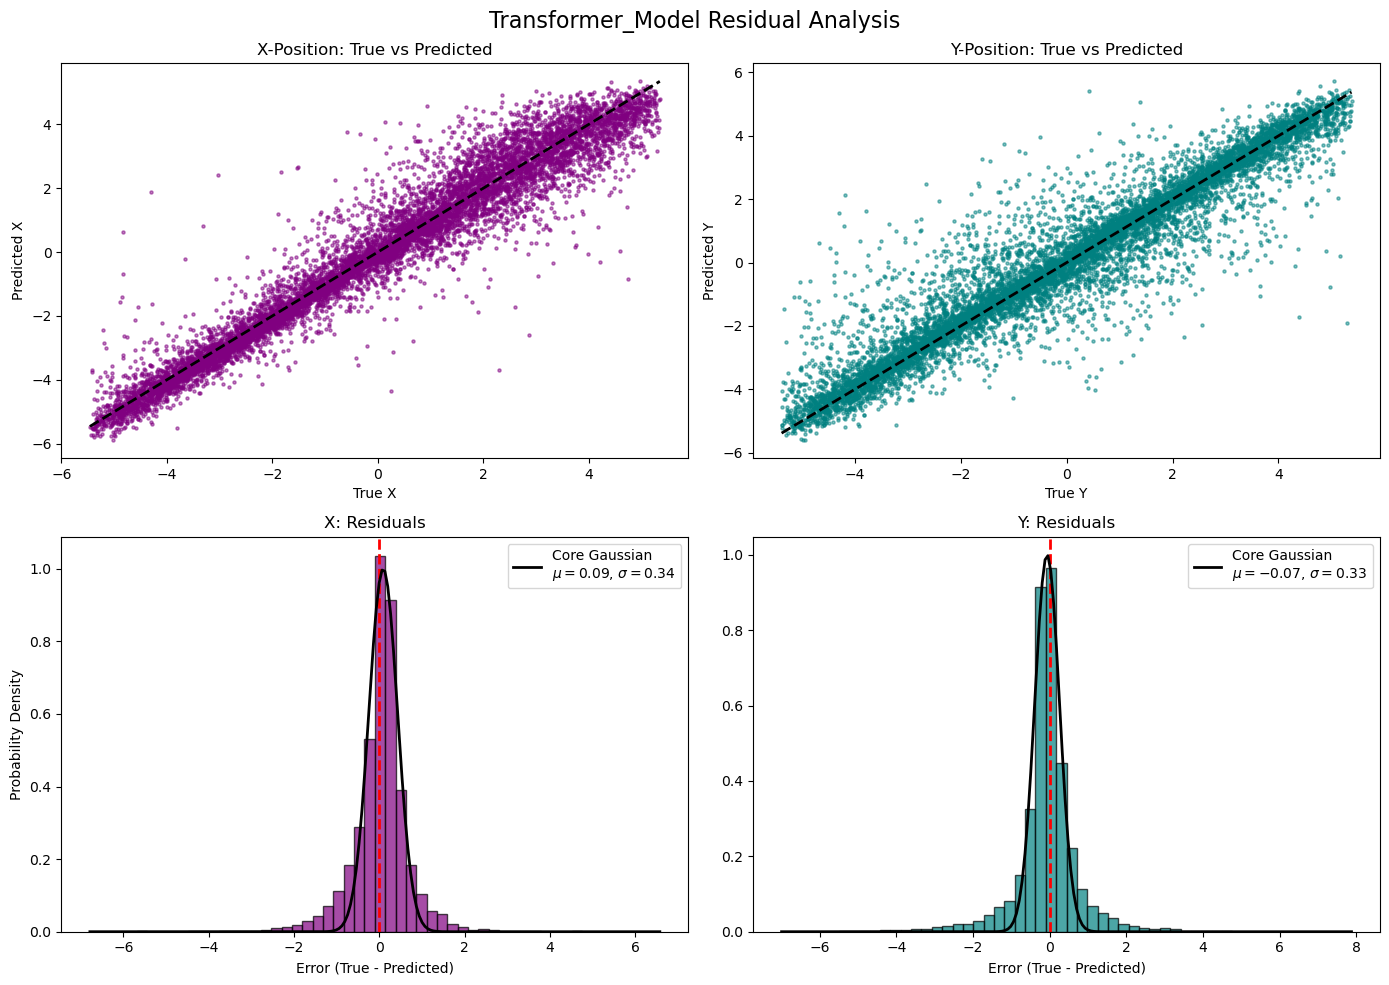

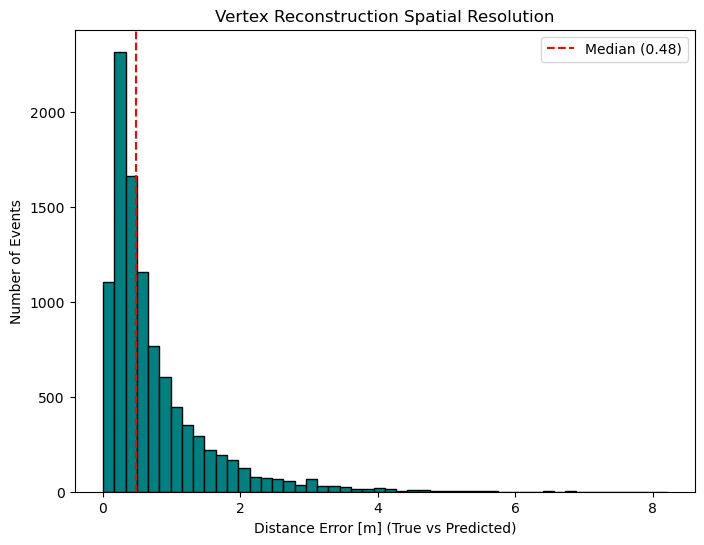

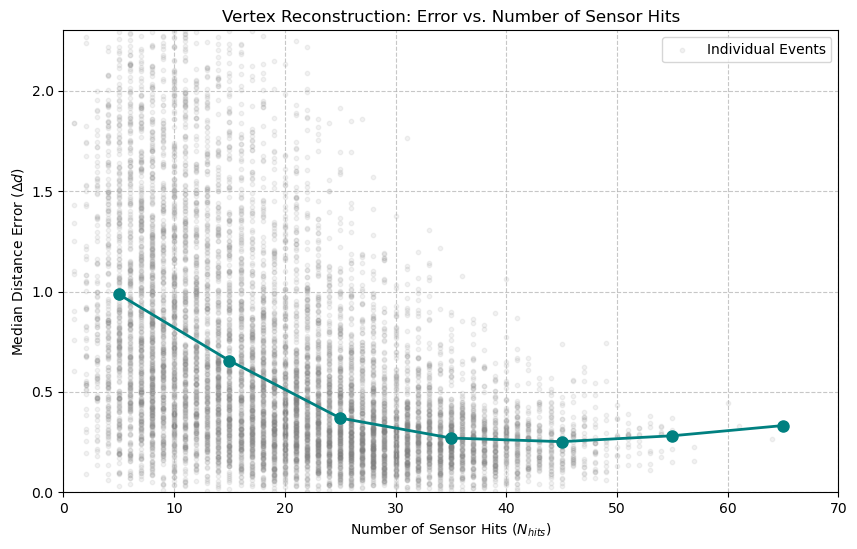

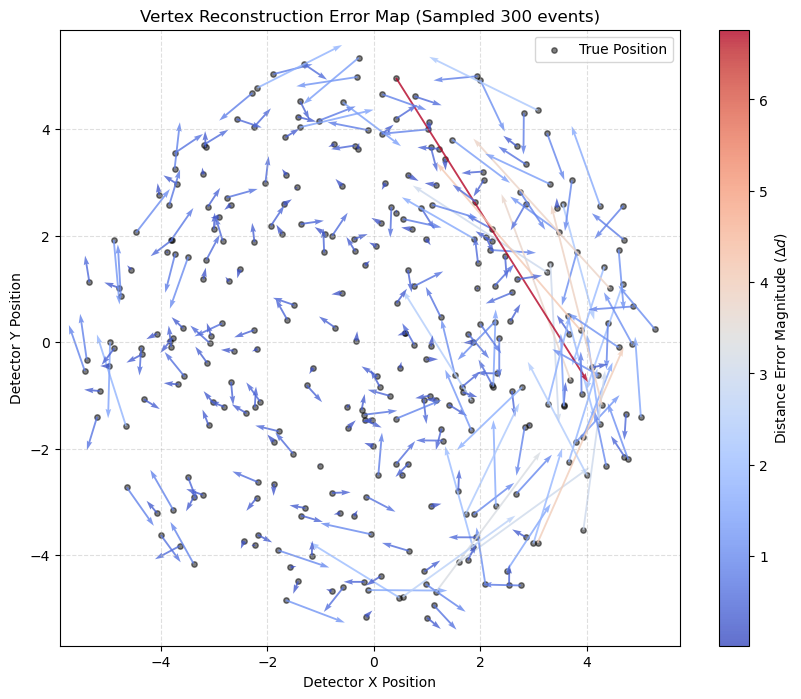

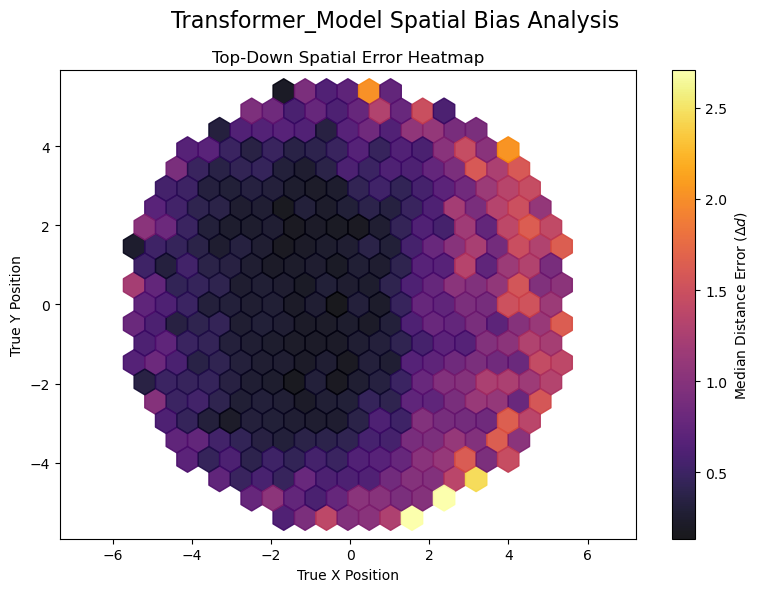

In [33]:
val_loss, distances, last_preds, last_labels = evaluate_model(model, test_loader, device)

In [34]:
model_2 = tt.TransformerEncoder(
    input_dim = 3,
    d_model = 64,
    output_dim = 2,
    num_layers = 4,
    nhead = 4,
)

model_2.to(device)

model_2_name = "transformer_encoder_model_2"

/Users/frederikzielke/Uni/Deep-Learning/Advanced/Transformers/transformer_encoder_template.py:86: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


In [35]:
train_losses_2, val_losses_2, best_model_2 = train_model(model_2, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience, device, model_name=model_2_name)

Epoch [1/100], Step [310/313], Loss: 0.7146
Epoch [1/100], Train Loss: 2.6158, Val Loss: 1.0078, Time: 9.92 seconds, Patience Counter: 0/10
Epoch [2/100], Step [310/313], Loss: 1.2492
Epoch [2/100], Train Loss: 0.8809, Val Loss: 0.8068, Time: 8.75 seconds, Patience Counter: 0/10
Epoch [3/100], Step [310/313], Loss: 0.3759
Epoch [3/100], Train Loss: 0.7437, Val Loss: 0.7355, Time: 8.44 seconds, Patience Counter: 0/10
Epoch [4/100], Step [310/313], Loss: 1.2789
Epoch [4/100], Train Loss: 0.6782, Val Loss: 0.6804, Time: 8.30 seconds, Patience Counter: 0/10
Epoch [5/100], Step [310/313], Loss: 0.6224
Epoch [5/100], Train Loss: 0.6409, Val Loss: 0.6496, Time: 7.98 seconds, Patience Counter: 0/10
Epoch [6/100], Step [310/313], Loss: 0.4169
Epoch [6/100], Train Loss: 0.6141, Val Loss: 0.6652, Time: 7.97 seconds, Patience Counter: 0/10
Epoch [7/100], Step [310/313], Loss: 0.6862
Epoch [7/100], Train Loss: 0.5970, Val Loss: 0.6152, Time: 8.08 seconds, Patience Counter: 1/10
Epoch [8/100], Step 

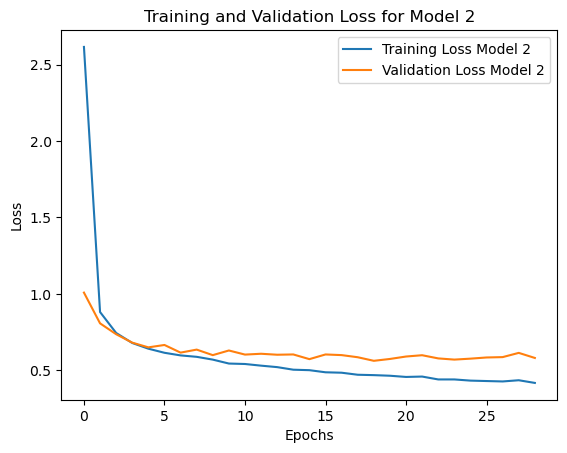

In [43]:
# plot losses
plt.plot(train_losses_2, label='Training Loss Model 2')
plt.plot(val_losses_2, label='Validation Loss Model 2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for Model 2')
plt.legend()
plt.savefig('model_2_loss_plot.png')  # Save the plot as a PNG file
plt.show()

Validation MSE Loss: 0.5661
Mean Error Distance: 0.70 meters
Median Error Distance: 0.42 meters

Generating evaluation plots...


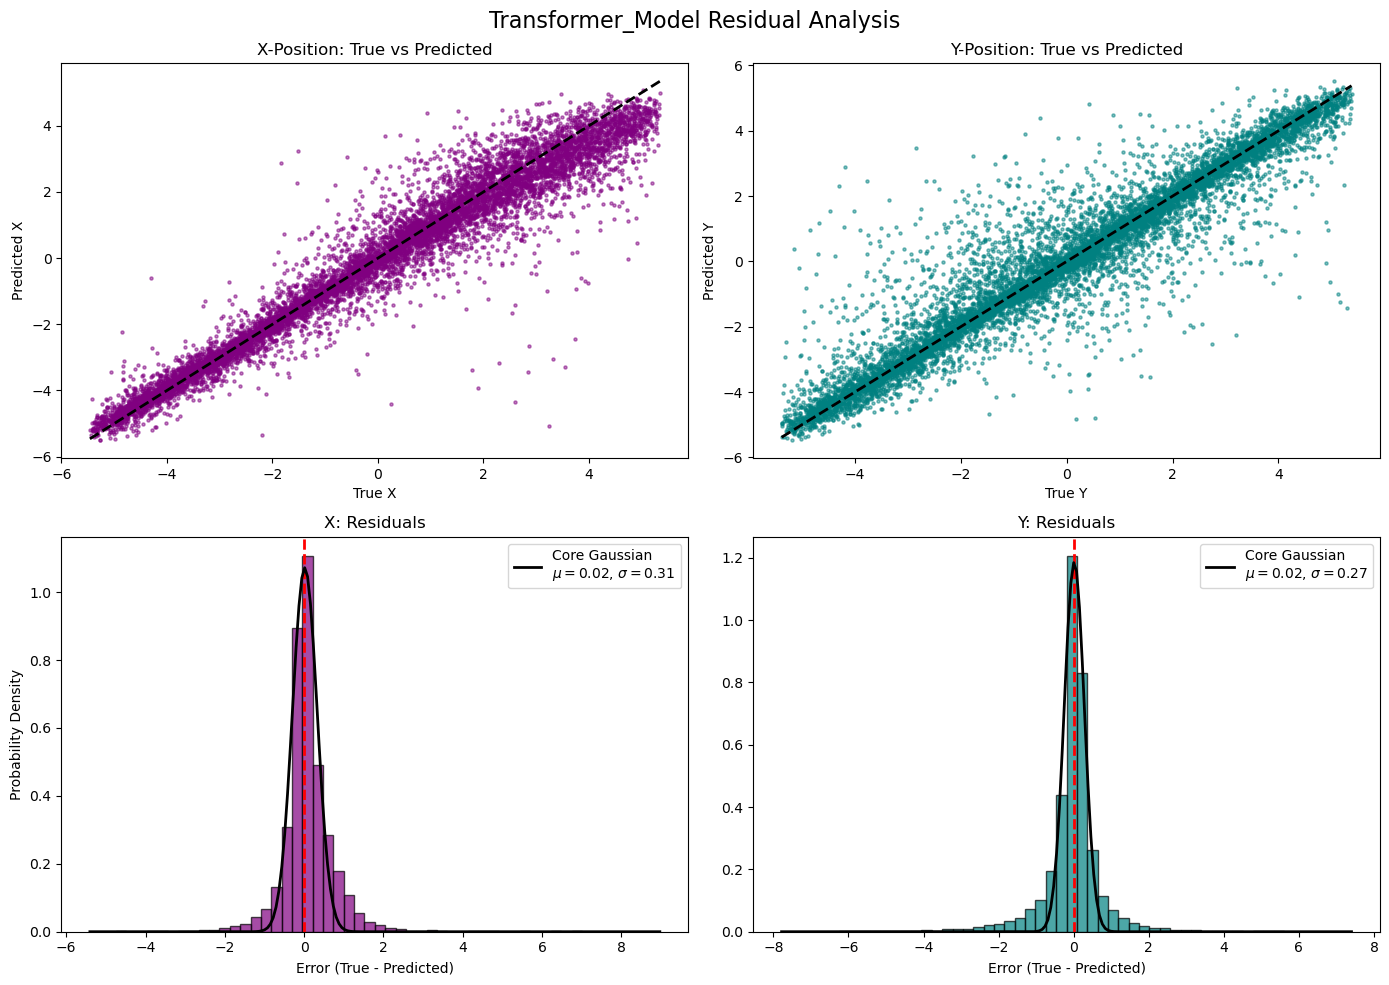

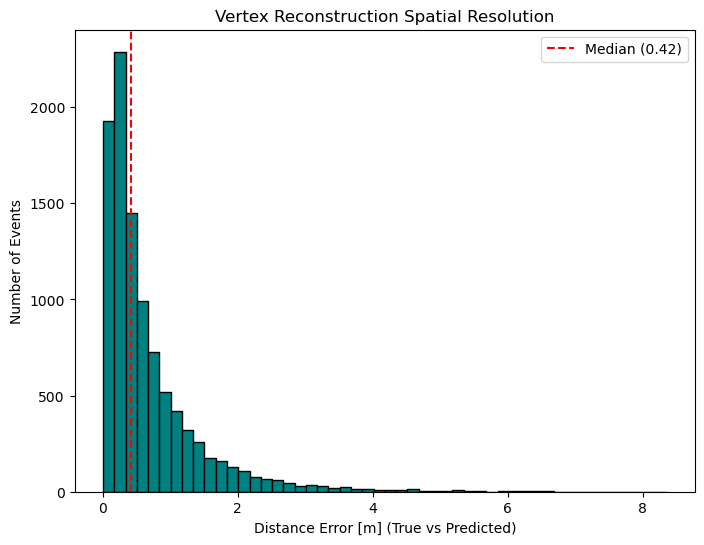

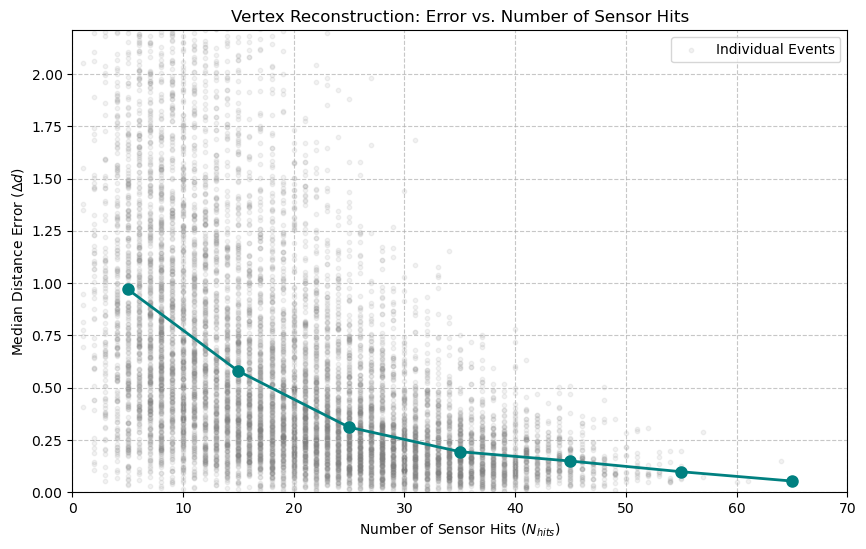

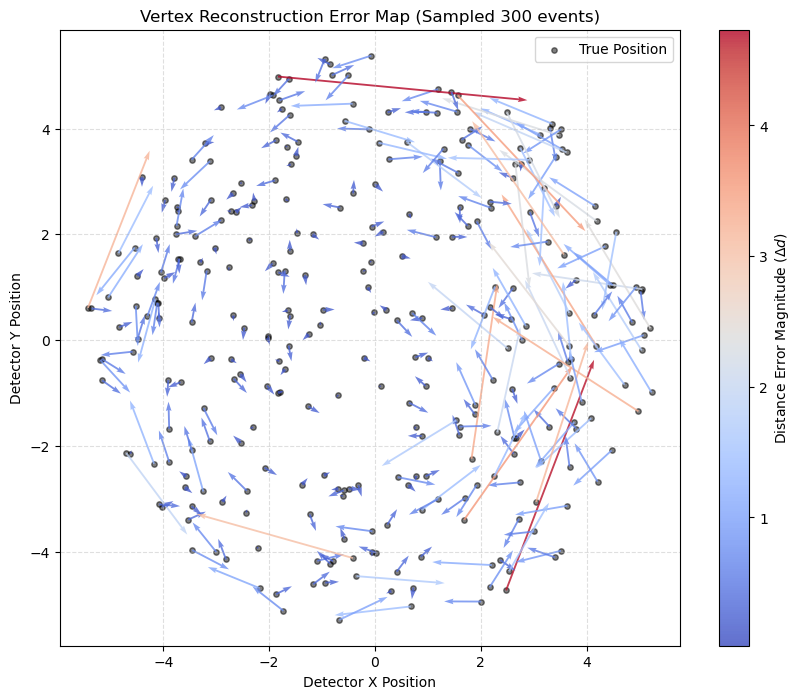

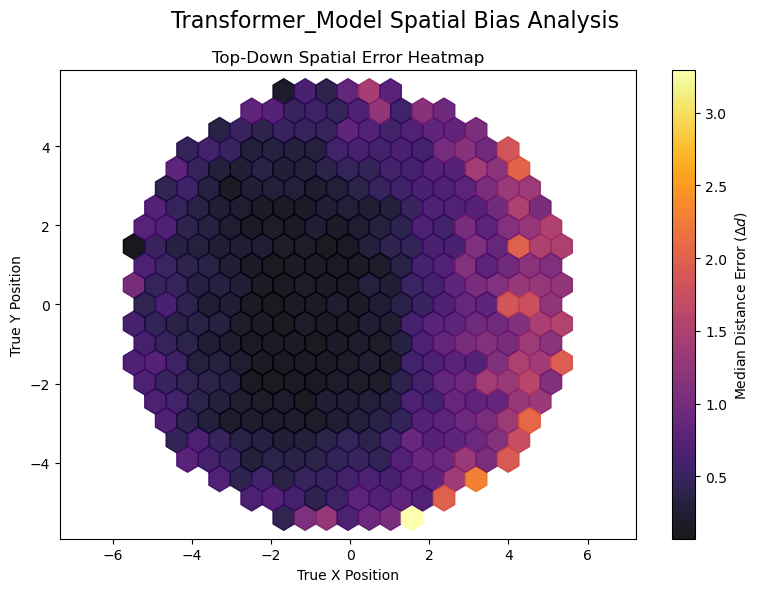

In [42]:
val_loss_2, distances_2, last_preds_2, last_labels_2 = evaluate_model(model_2, test_loader, device)

In [38]:
model_3 = tt.TransformerEncoder(
    input_dim = 3,
    d_model = 128,
    output_dim = 2,
    num_layers = 4,
    nhead = 4,
)

model_3.to(device)

model_3_name = "transformer_encoder_model_3"

In [39]:
train_losses_3, val_losses_3, best_model_3 = train_model(model_3, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience, device, model_name=model_3_name)

Epoch [1/100], Step [310/313], Loss: 1.0665
Epoch [1/100], Train Loss: 1.4401, Val Loss: 0.8325, Time: 11.75 seconds, Patience Counter: 0/10
Epoch [2/100], Step [310/313], Loss: 0.7397
Epoch [2/100], Train Loss: 0.7305, Val Loss: 0.7673, Time: 8.99 seconds, Patience Counter: 0/10
Epoch [3/100], Step [310/313], Loss: 0.8895
Epoch [3/100], Train Loss: 0.6732, Val Loss: 0.6855, Time: 8.78 seconds, Patience Counter: 0/10
Epoch [4/100], Step [310/313], Loss: 0.4688
Epoch [4/100], Train Loss: 0.6188, Val Loss: 0.6516, Time: 8.27 seconds, Patience Counter: 0/10
Epoch [5/100], Step [310/313], Loss: 0.4546
Epoch [5/100], Train Loss: 0.5898, Val Loss: 0.6493, Time: 8.33 seconds, Patience Counter: 0/10
Epoch [6/100], Step [310/313], Loss: 0.7134
Epoch [6/100], Train Loss: 0.5754, Val Loss: 0.6582, Time: 8.30 seconds, Patience Counter: 0/10
Epoch [7/100], Step [310/313], Loss: 0.3828
Epoch [7/100], Train Loss: 0.5478, Val Loss: 0.6312, Time: 8.27 seconds, Patience Counter: 1/10
Epoch [8/100], Step

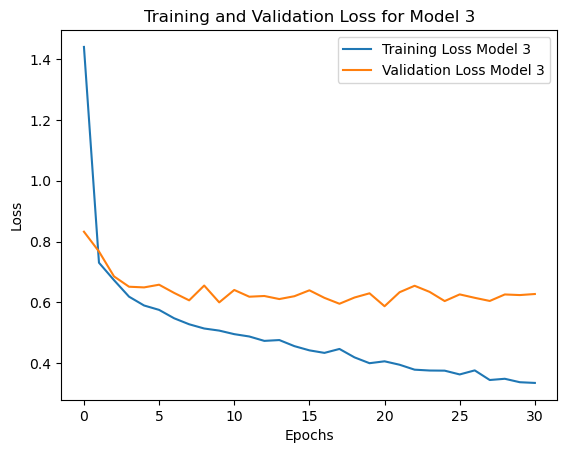

In [40]:
plt.plot(train_losses_3, label='Training Loss Model 3')
plt.plot(val_losses_3, label='Validation Loss Model 3')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for Model 3')
plt.legend()
plt.show()

Validation MSE Loss: 0.5970
Mean Error Distance: 0.71 meters
Median Error Distance: 0.43 meters

Generating evaluation plots...


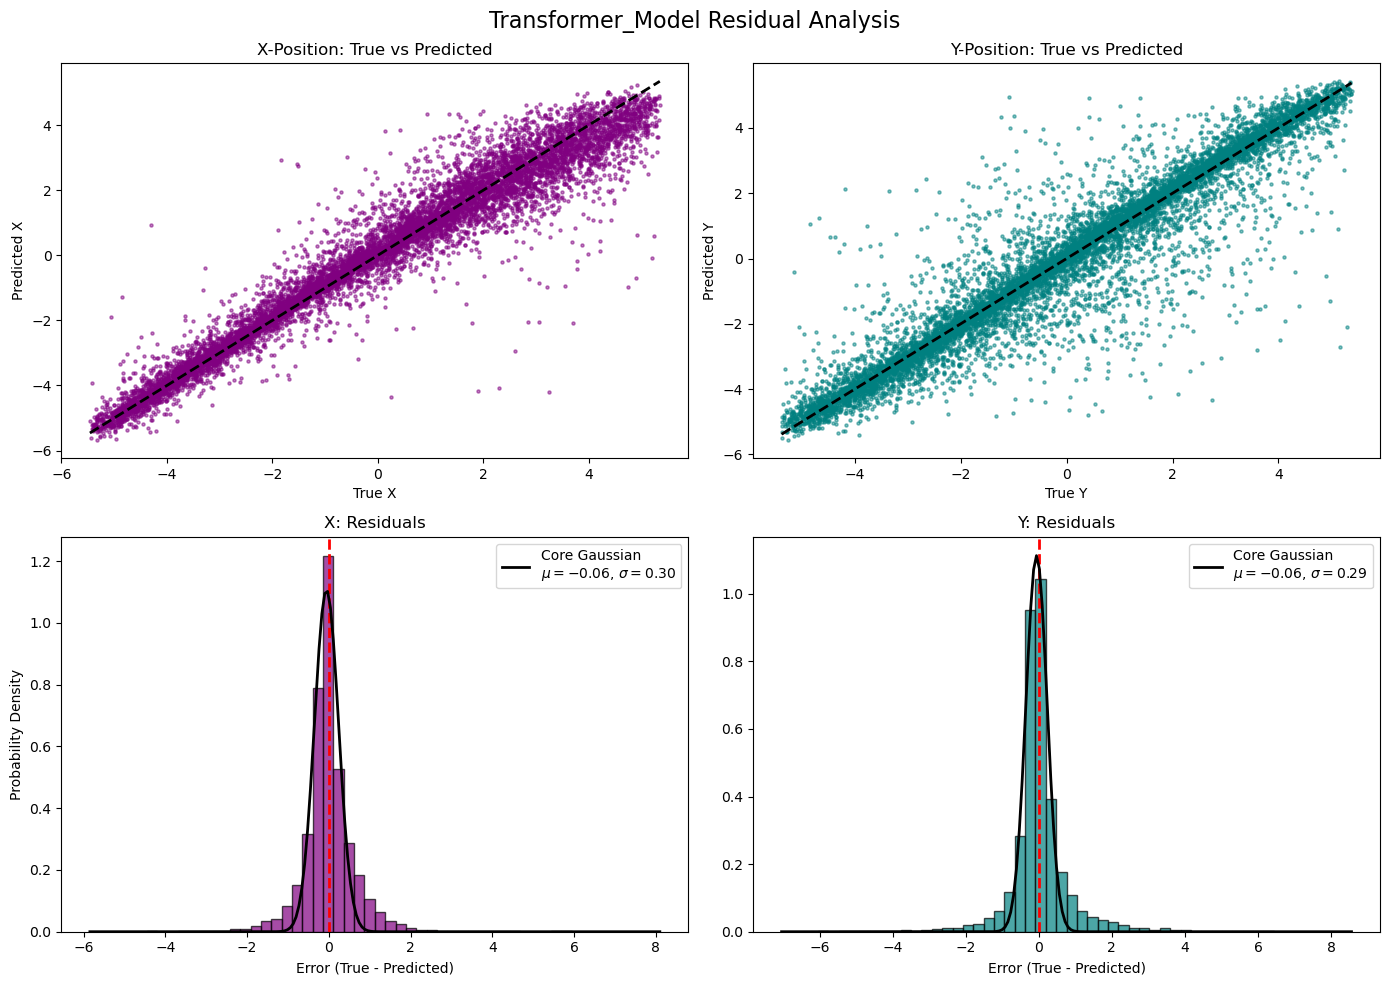

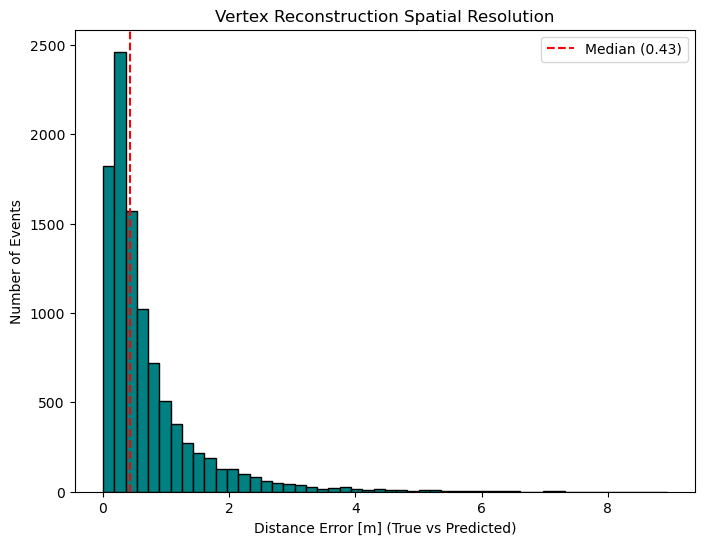

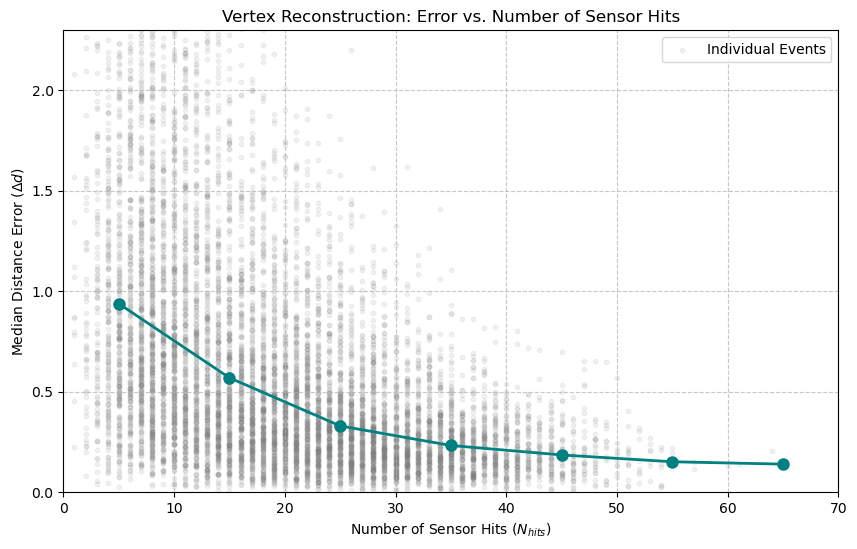

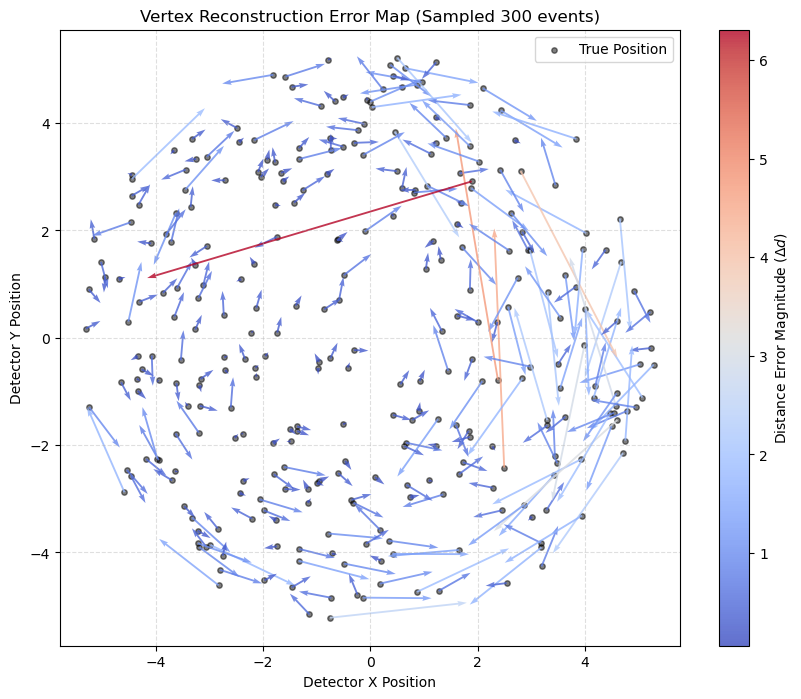

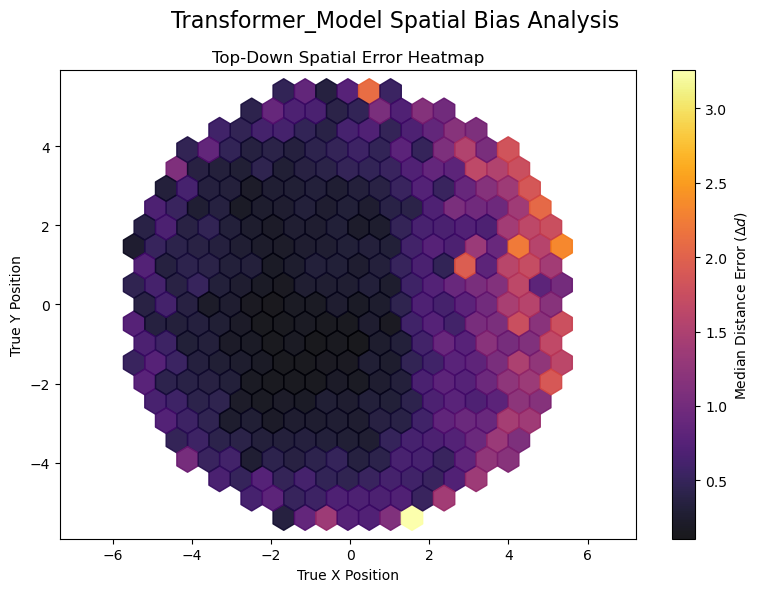

In [41]:
val_loss_3, distances_3, last_preds_3, last_labels_3 = evaluate_model(model_3, test_loader, device)